
# Dynamic Hedge Pairs Trading — Hyperparameter Tuning

## `pairs_trading_04_hyperparameter_tuning.ipynb`

A copy of `pairs_trading_02.ipynb` — the clean end-to-end spine (cointegration screen → Kalman hedge →
walk-forward pair selection → in-sample and OOS evaluation) — with one addition: **§3.6 tunes the
hyperparameters that nb02 hard-codes**, using walk-forward folds on the training window only, and
**§4/§4b evaluate the default and the tuned configuration side by side on the same 2026 hold-out.**

What nb02 fixes by hand and what is tuned here:

| group | hyperparameter | nb02 default | note |
|---|---|---|---|
| Kalman | `q` (transition noise) | 1e-5 | with `em_iters>0` it is only the EM starting value |
| Kalman | `em_iters` | 5 | EM re-estimates Q and R on each training window |
| signals | `z_method` | robust | robust / rolling |
| signals | `z_entry`, `z_exit`, `z_stop` | 2.0 / 0.5 / 4.0 | thresholds on \|z\| |
| signals | `max_hold_bars`, `cooldown_bars` | None / 0 | holding cap, re-entry cooldown |

Everything up to §3.5 is identical to nb02 (the pair is still selected with the default parameters, so
tuning never sees the 2026 data), except that downloaded prices and the screening table are cached
under `notebooks/cache/` (gitignored) to make re-runs cheap.

Re-run from top to bottom; self-contained.


## 0. Environment setup

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
print("pairs version:", pairs.__version__)
print("pairs path   :", pairs.__file__)

pairs version: 0.1.0
pairs path   : /Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading/pairs/__init__.py


In [2]:
# Install the package (editable) if running in a fresh environment
# %pip install -e "..[notebooks]"  # uncomment if needed

# 1. Data Loading & Quality Filtering

We load daily OHLCV prices for the combined S&P 500 + NASDAQ-100 universe
(~517 tickers) over the **training window 2020-01-01 → 2025-12-31**, then
drop tickers whose coverage does not span the full period.

In [3]:
from pairs import load_universe, load_prices

tickers = load_universe("spx_ndx_combined")
print(f"Universe: {len(tickers)} tickers")

Universe: 517 tickers


In [4]:

# ── Load training prices (cached under notebooks/cache/, gitignored) ──────────
start_date = "2020-01-01"
end_date   = "2025-12-31"

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
_px_cache = CACHE / "nb04_train_prices.parquet"
if _px_cache.exists():
    df_train, failed = pd.read_parquet(_px_cache), []
    print(f"Loaded cached prices from {_px_cache}")
else:
    df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)
    df_train.to_parquet(_px_cache)

print(f"Loaded {len(df_train):,} rows for {df_train.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)


Download:   0%|          | 0/517 [00:00<?, ?it/s]

A:   0%|          | 0/517 [00:00<?, ?it/s]       

A:   0%|          | 1/517 [00:00<05:41,  1.51it/s]

AAPL:   0%|          | 1/517 [00:00<05:41,  1.51it/s]

AAPL:   0%|          | 2/517 [00:00<03:14,  2.64it/s]

...

ZS: 100%|█████████▉| 516/517 [01:32<00:00,  6.53it/s]

ZTS: 100%|█████████▉| 516/517 [01:32<00:00,  6.53it/s]

ZTS: 100%|██████████| 517/517 [01:32<00:00,  6.40it/s]

ZTS: 100%|██████████| 517/517 [01:32<00:00,  5.60it/s]

Loaded 753,000 rows for 505 tickers
No data for: ['AVB', 'BK', 'CTRA', 'DAY', 'EA', 'EQR', 'FI', 'HOLX', 'IPG', 'K', 'MMC', 'WBA']


In [5]:
# ── Quality filter: keep only full-coverage tickers ──────────────────────────
lvl_names      = list(df_train.index.names)
time_lvl_name  = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

starts = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).min())
ends   = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).max())

tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index
df_filtered     = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

n_orig    = df_train.index.get_level_values('ticker').nunique()
n_kept    = df_filtered.index.get_level_values('ticker').nunique()
dropped   = set(tickers) - set(tickers_to_keep)
print(f"Tickers: {n_orig} total → {n_kept} kept ({n_orig - n_kept} dropped for incomplete coverage)")
print(f"Dropped: {sorted(dropped)}")

Tickers: 505 total → 488 kept (17 dropped for incomplete coverage)
Dropped: ['ABNB', 'APP', 'ARM', 'AVB', 'BK', 'CARR', 'CEG', 'COIN', 'CTRA', 'DASH', 'DAY', 'EA', 'EQR', 'EXE', 'FI', 'GEHC', 'GEV', 'GFS', 'HOLX', 'IPG', 'K', 'KVUE', 'MMC', 'OTIS', 'PARA', 'PLTR', 'SOLV', 'VLTO', 'WBA']


# 2. Cointegration Screening

## 2.1 Dual-gate screening (Engle-Granger + Johansen)

We test all $\binom{n}{2}$ pairs simultaneously using two cointegration tests.
A pair advances only if **both** tests reject the null of no cointegration.

In [6]:

from pairs import find_cointegrated_pairs_dualgate

# fdr_method="bh" is the default — BH correction is applied automatically.
# The screen is the slowest step (~120k pairs); cache the result table.
_screen_cache = CACHE / "nb04_screen.parquet"
if _screen_cache.exists():
    summary_dual = pd.read_parquet(_screen_cache)
    print(f"Loaded cached screen from {_screen_cache}")
else:
    summary_dual = find_cointegrated_pairs_dualgate(
        df_filtered,
        alpha_eg=0.05, eg_trend="c",
        alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
        fdr_method="bh",
        n_workers=16, chunksize=8, show_progress=True,
    )
    summary_dual.to_parquet(_screen_cache)

print(f"\nTotal pairs screened : {len(summary_dual):,}")
print(f"Dual-gate pass (verdict=='pass'): {(summary_dual['verdict']=='pass').sum()}")
print("\nColumn eg_p_fdr contains BH-adjusted p-values:")
summary_dual.head(5)[["eg_t","eg_p","eg_p_fdr","eg_pass","joh_stat","joh_pass","verdict"]]


Dual-gate cointegration (EG + Johansen):   0%|          | 0/118828 [00:00<?, ?it/s]

Dual-gate cointegration (EG + Johansen):   1%|          | 1081/118828 [00:00<00:28, 4201.71it/s]

Dual-gate cointegration (EG + Johansen):   1%|▏         | 1502/118828 [00:00<01:28, 1328.54it/s]

Dual-gate cointegration (EG + Johansen):   1%|▏         | 1711/118828 [00:01<01:51, 1051.52it/s]

Dual-gate cointegration (EG + Johansen):   2%|▏         | 1851/118828 [00:01<02:11, 889.15it/s] 

...

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118593/118828 [03:58<00:00, 508.69it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118657/118828 [03:59<00:00, 484.88it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118707/118828 [03:59<00:00, 423.39it/s]


Total pairs screened : 118,828
Dual-gate pass (verdict=='pass'): 279

Column eg_p_fdr contains BH-adjusted p-values:


eg_t          eg_p  eg_p_fdr  eg_pass   joh_stat  \
ticker1 ticker2                                                         
NCLH    SHOP    -6.892330  1.544746e-08  0.001355     True  37.268515   
        TRMB    -6.774412  2.923744e-08  0.001355     True  42.340817   
        XYZ     -6.691579  4.559848e-08  0.001355     True  34.453662   
        ZBRA    -6.725933  3.793752e-08  0.001355     True  36.397732   
        PNC     -6.514035  1.169097e-07  0.002069     True  33.278533   

                 joh_pass verdict  
ticker1 ticker2                    
NCLH    SHOP         True    pass  
        TRMB         True    pass  
        XYZ          True    pass  
        ZBRA         True    pass  
        PNC          True    pass

## 2.2 Multiple Testing Correction — Benjamini-Hochberg (BH) FDR

### Why it matters

We test $N(N-1)/2$ pairs simultaneously at $\alpha = 0.05$.
By chance alone, the expected number of false positives is:
$$
\text{E}[\text{FP}] = \alpha \times M \approx 0.05 \times 121{,}771 \approx 6{,}089
$$

The **Benjamini-Hochberg (1995)** procedure controls the *False Discovery Rate* — the
expected fraction of false positives among all rejected hypotheses — at level $\alpha$.
It is far less conservative than Bonferroni while still being statistically principled.

`find_cointegrated_pairs_dualgate` now:
- applies BH to all EG p-values before gating,
- stores the adjusted p-value in the `eg_p_fdr` column, and
- warns if and how many raw-significant pairs were removed.

In [7]:
from pairs import benjamini_hochberg_fdr

# Post-hoc illustration using the raw EG p-values from summary_dual
alpha_fdr = 0.05
raw_pvals = summary_dual["eg_p"].values
reject_bh, padj = benjamini_hochberg_fdr(raw_pvals, alpha=alpha_fdr)

n_raw = int((raw_pvals <= alpha_fdr).sum())
n_fdr = int(reject_bh.sum())
n_tests = len(raw_pvals)

print(f"Total pairs tested         : {n_tests:>8,}")
print(f"Expected false positives   : {n_tests * alpha_fdr:>8,.0f}  (= {n_tests} × {alpha_fdr})")
print(f"Raw EG significant (p≤.05) : {n_raw:>8,}")
print(f"After BH correction        : {n_fdr:>8,}  ({n_raw - n_fdr:+d} removed)")

Total pairs tested         :  118,828
Expected false positives   :    5,941  (= 118828 × 0.05)
Raw EG significant (p≤.05) :    8,923
After BH correction        :      280  (+8643 removed)


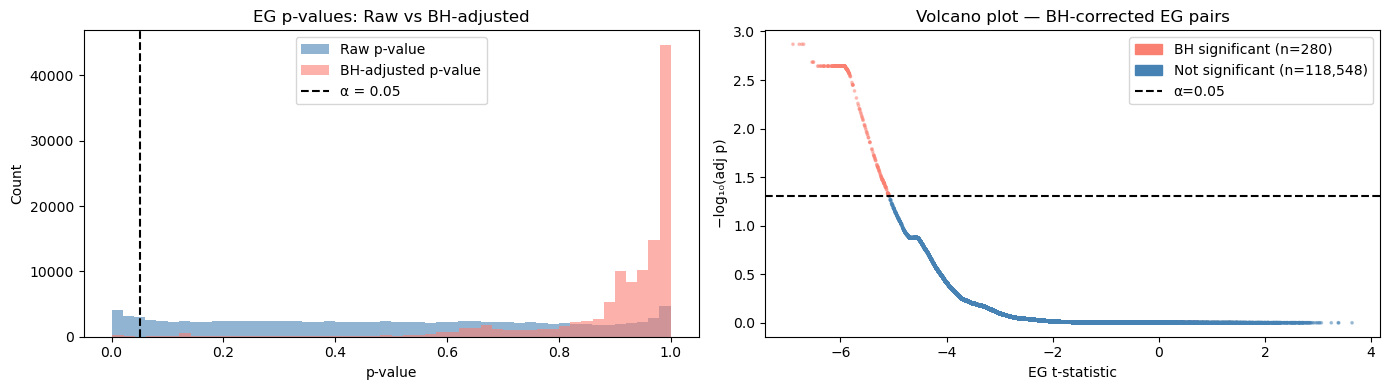


Conclusion: BH removes 8,643 of 8,923 raw-significant pairs, keeping 280 with FDR ≤ 5%.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of raw vs BH-adjusted p-values
ax = axes[0]
ax.hist(raw_pvals, bins=50, alpha=0.6, label="Raw p-value", color="steelblue")
ax.hist(padj,      bins=50, alpha=0.6, label="BH-adjusted p-value", color="salmon")
ax.axvline(alpha_fdr, color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("p-value"); ax.set_ylabel("Count")
ax.set_title("EG p-values: Raw vs BH-adjusted"); ax.legend()

# Right: volcano plot (t-statistic vs –log10 adj p)
ax = axes[1]
log_padj = -np.log10(np.clip(padj, 1e-300, 1.0))
colours  = np.where(reject_bh, "salmon", "steelblue")
ax.scatter(summary_dual["eg_t"].values, log_padj, c=colours, s=3, alpha=0.4)
ax.axhline(-np.log10(alpha_fdr), color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("EG t-statistic"); ax.set_ylabel("−log₁₀(adj p)")
ax.set_title("Volcano plot — BH-corrected EG pairs")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="salmon",    label=f"BH significant (n={n_fdr:,})"),
    Patch(color="steelblue", label=f"Not significant (n={n_tests-n_fdr:,})"),
    plt.Line2D([0],[0], color="black", linestyle="--", label=f"α={alpha_fdr}"),
])
plt.tight_layout(); plt.show()
print(f"\nConclusion: BH removes {n_raw-n_fdr:,} of {n_raw:,} raw-significant pairs, "
      f"keeping {n_fdr:,} with FDR ≤ {alpha_fdr:.0%}.")

## 2.3 Pre-scoring: rank candidates for Kalman filtering

We rank all pairs by a composite rank score (EG p-value + Johansen statistic) and
take the top 200 as candidates for the computationally expensive Kalman step.

In [9]:
tmp = summary_dual.copy()
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
tmp["pre_score"] = 0.5 * (tmp["rank_eg"] / tmp["rank_eg"].max()
                         + tmp["rank_joh"] / tmp["rank_joh"].max())
prelim     = tmp.sort_values("pre_score", ascending=True)
candidates = prelim.head(200).index.to_list()
print(f"Candidates selected for Kalman filtering: {len(candidates)}")

Candidates selected for Kalman filtering: 200


# 3. Kalman Filter Hedge Estimation & Stationarity Scoring

## 3.1 Kalman filter model overview

We estimate a **time-varying** hedge ratio $\beta_t$ via a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = \begin{bmatrix}\beta_t \\ \alpha_t\end{bmatrix}, \qquad
\theta_t = \theta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)
$$

Parameters $Q$ and $R$ are learned by EM; the filter is then run in smoother mode
for in-sample residuals and in **filter mode** (no look-ahead) for OOS evaluation.

In [10]:
from pairs import fit_kalman_hedge, summarize_spread_stationarity_joblib

states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="smooth",
    em_iters=5,
    q=1e-5,
    n_workers=None,
    chunksize=100,
    show_progress=True,
    return_params=True,
)
print(f"Kalman states computed for {len(states_tr)} pairs")

Kalman (α_t, β_t):   0%|          | 0/200 [00:00<?, ?it/s]

Kalman (α_t, β_t):   1%|          | 2/200 [00:04<07:14,  2.19s/it]

Kalman (α_t, β_t):   8%|▊         | 16/200 [00:04<00:37,  4.86it/s]

Kalman (α_t, β_t):  16%|█▌        | 32/200 [00:04<00:14, 11.31it/s]

Kalman (α_t, β_t):  21%|██        | 42/200 [00:06<00:16,  9.32it/s]

...

Kalman (α_t, β_t):  94%|█████████▍| 188/200 [00:20<00:00, 12.82it/s]

Kalman (α_t, β_t):  96%|█████████▌| 192/200 [00:20<00:00, 15.74it/s]

Kalman (α_t, β_t):  97%|█████████▋| 194/200 [00:21<00:00,  9.17it/s]

Kalman (α_t, β_t):  98%|█████████▊| 196/200 [00:21<00:00, 10.34it/s]

Kalman states computed for 200 pairs


## 3.2 Spread stationarity diagnostics

For each pair we run:
1. **ADF** (Augmented Dickey-Fuller) — reject $H_0$ of unit root → spread is I(0)
2. **KPSS** — fail to reject $H_0$ of stationarity → spread is I(0)

**Verdict**: `stationary` if ADF rejects AND KPSS does not reject; `non-stationary` if vice versa;
`inconclusive` otherwise.

Additional diagnostics: **half-life** (AR(1) proxy for mean-reversion speed) and
**residual sigma** (spread volatility).

In [11]:
summary_stationarity = summarize_spread_stationarity_joblib(
    states_tr, alpha=0.05, regression="c", chunksize=256, show_progress=True
)
print(f"\n{len(summary_stationarity)} pairs tested")
summary_stationarity.head(10)

Testing stationarity:   0%|          | 0/200 [00:00<?, ?it/s]

Testing stationarity:   1%|          | 2/200 [00:01<01:44,  1.90it/s]

Testing stationarity:  23%|██▎       | 46/200 [00:01<00:02, 54.29it/s]

Testing stationarity:  55%|█████▍    | 109/200 [00:01<00:00, 138.27it/s]

Testing stationarity:  84%|████████▍ | 169/200 [00:01<00:00, 217.75it/s]


200 pairs tested


adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
NCLH    ZTS     -12.527885  2.465476e-23   0.485533  0.044925       NaN   
ADI     HCA     -19.593265  0.000000e+00   0.135975  0.100000       NaN   
CCL     MU      -19.272545  0.000000e+00   0.069266  0.100000  0.232378   
        EXPE    -18.342974  2.244177e-30   0.243112  0.100000  0.119303   
        PTC     -17.019002  8.483731e-30   0.022442  0.100000  0.271345   
NCLH    OXY     -17.008413  8.626829e-30   0.013154  0.100000  1.056807   
        PYPL    -16.398703  2.651010e-29   0.025854  0.100000       NaN   
        WBD     -15.776765  1.143737e-28   0.024887  0.100000  0.939727   
        SBAC    -15.526080  2.251362e-28   0.126668  0.100000       NaN   
        VTR     -14.636660  3.679130e-27   0.025032  0.100000  0.393573   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
NCLH    ZTS         0.273615 -0.016373  inconclusive  
ADI     HCA         1.214312 -0.007542    stationary  
CCL     MU          0.337396 -0.035293    stationary  
        EXPE        0.266665 -0.017030    stationary  
        PTC         0.346568 -0.029031    stationary  
NCLH    OXY         0.706541 -0.055483    stationary  
        PYPL        0.257460 -0.011663    stationary  
        WBD         0.661124 -0.022014    stationary  
        SBAC        0.224056 -0.018083    stationary  
        VTR         0.472053 -0.025990    stationary

## 3.3 Composite scoring

Convert heterogeneous metrics into comparable z-scores (higher = better), then take a
weighted sum:

| Metric | Transform | Direction |
|--------|-----------|-----------|
| ADF p-value | $-\log_{10}(p)$ then $Z(\cdot)$ | smaller p → better |
| KPSS p-value | $Z(p)$ | larger p → better |
| Half-life | $-\log(1+\text{hl})$ then $Z(\cdot)$ | shorter → better |
| Residual sigma | $Z(-\sigma)$ | smaller → better |
| Sharpe (train) | $Z(\text{Sharpe})$ | higher → better |

In [12]:
from pairs.stats import Z

final_df = summary_stationarity.copy()
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "sharpe_train"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

sharpe_series = final_df.get("sharpe_train", pd.Series(0.0, index=final_df.index))
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)

components = {
    "adf":    Z(-np.log10(p_adf)),
    "kpss":   Z(p_kpss),
    "hl":     Z(-np.log1p(hl_safe)),
    "sigma":  Z(-final_df["resid_sigma"]),
    "sharpe": Z(sharpe_series),
}
weights = {k: 1.0 for k in components}
final_df["score"] = sum(weights[k] * components[k] for k in components)
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)

adf_stat         adf_p  kpss_stat  kpss_p  halflife  \
ticker1 ticker2                                                         
CCL     MU      -19.272545  0.000000e+00   0.069266     0.1  0.232378   
        EXPE    -18.342974  2.244177e-30   0.243112     0.1  0.119303   
NCLH    VMC     -13.786825  9.079420e-26   0.025438     0.1  0.138855   
CCL     COF     -14.118492  2.448494e-26   0.042896     0.1  0.173511   
NCLH    TEL     -13.149301  1.377465e-24   0.026165     0.1  0.136397   
        O       -13.438819  3.881575e-25   0.067648     0.1  0.116208   
        TMUS    -11.331011  1.112772e-20   0.031405     0.1  0.111537   
        QCOM    -13.233756  9.469455e-25   0.028904     0.1  0.185669   
        TER     -12.245855  9.787668e-23   0.054451     0.1  0.164812   
        PAYX    -14.352664  1.015553e-26   0.022282     0.1  0.181692   

                 resid_sigma    shapre     verdict      score  
ticker1 ticker2                                                
CCL     MU          0.337396 -0.035293  stationary  11.055536  
        EXPE        0.266665 -0.017030  stationary   1.919361  
NCLH    VMC         0.317369 -0.010544  stationary   1.544850  
CCL     COF         0.280247 -0.013437  stationary   1.530605  
NCLH    TEL         0.315855 -0.011760  stationary   1.515728  
        O           0.371002 -0.033013  stationary   1.470306  
        TMUS        0.322501 -0.021915  stationary   1.454724  
        QCOM        0.314735 -0.010578  stationary   1.338057  
        TER         0.325360 -0.002386  stationary   1.315683  
        PAYX        0.365987 -0.014739  stationary   1.289975

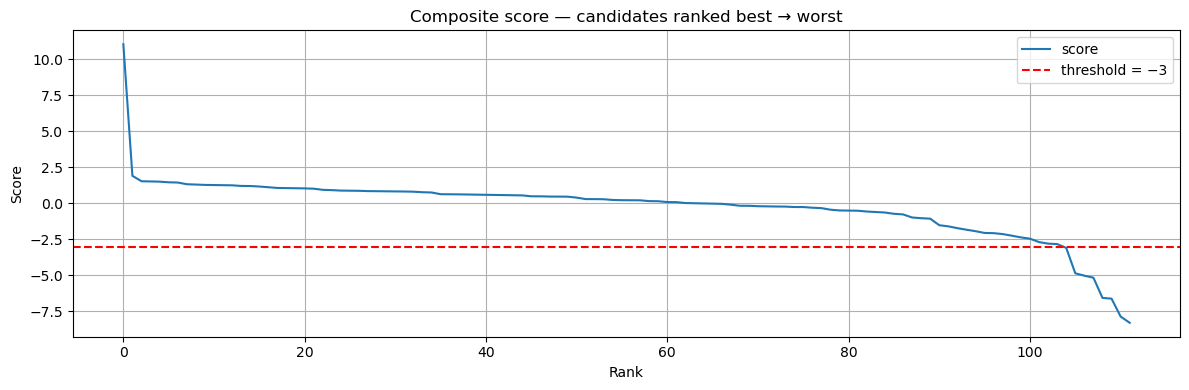

In [13]:
ranked['score'].reset_index(drop=True).plot(
    figsize=(12, 4), grid=True,
    title="Composite score — candidates ranked best → worst",
    xlabel="Rank", ylabel="Score",
)
plt.axhline(-3, color="red", linestyle="--", lw=1.5, label="threshold = −3")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs    = ranked_positive.index
print(f"Candidates: {len(candidates)}  →  Robust pairs (score > −3): {len(robust_pairs)}")

Candidates: 200  →  Robust pairs (score > −3): 104


## 3.4 Pre-filter candidates (composite score)

The composite score from §3.3 is **only a cheap pre-filter** — it narrows the robust pairs down to a short list of candidates. It does **not** pick the traded pair: selecting the single best *in-sample* score is exactly the overfitting trap we want to avoid (it's what produced the inflated CCL/EXPE in-sample Sharpe).

The final pair is chosen in **§3.5** by **walk-forward cross-fold stability**, using only training-span data (2020–2025). The 2026 window (§4b) is never consulted for selection — it stays a genuine held-out test.

In [15]:
# Composite score is a CHEAP PRE-FILTER only — it does NOT pick the final pair.
# Take the top-N robust candidates; the walk-forward driver in §3.5 selects among them.
N_CANDIDATES = 15
wf_candidates = list(robust_pairs[:N_CANDIDATES])

print(f"Pre-filtered to top {len(wf_candidates)} candidates by composite score "
      f"(of {len(robust_pairs)} robust pairs). Final pick is deferred to §3.5.")
for i, (t1, t2) in enumerate(wf_candidates, 1):
    print(f"  {i:2d}. {t1:6s}/{t2:6s}  score={ranked.loc[(t1, t2), 'score']:.3f}")

Pre-filtered to top 15 candidates by composite score (of 104 robust pairs). Final pick is deferred to §3.5.
   1. CCL   /MU      score=11.056
   2. CCL   /EXPE    score=1.919
   3. NCLH  /VMC     score=1.545
   4. CCL   /COF     score=1.531
   5. NCLH  /TEL     score=1.516
   6. NCLH  /O       score=1.470
   7. NCLH  /TMUS    score=1.455
   8. NCLH  /QCOM    score=1.338
   9. NCLH  /TER     score=1.316
  10. NCLH  /PAYX    score=1.290
  11. NCLH  /PRU     score=1.282
  12. NCLH  /SPG     score=1.273
  13. NCLH  /OMC     score=1.261
  14. CCL   /META    score=1.219
  15. CCL   /STT     score=1.212


## 3.5 Walk-forward selection driver  ← *this* picks the traded pair

We run walk-forward validation (rolling train/test folds over the 2020–2025 training span) on **each** pre-filtered candidate and rank by the **median per-fold Sharpe**. Median rewards pairs whose edge is *consistent across folds* rather than pairs that got one lucky window. `MIN_TOTAL_TRADES` screens out pairs too inactive to judge.

This is the holdout principle done correctly for time series: **selection happens on validation folds**; the 2026 test set in §4b is never touched here. The top-ranked pair becomes `ticker1, ticker2` for everything downstream.

The z-score look-back for each test fold is estimated from the *training* fold's residual, which also warms up the rolling window — the test fold never informs its own z-score (no in-fold look-ahead).

In [16]:
# === Walk-forward selection driver (parallel across candidates) =============
# Each candidate's walk-forward run is independent, so we fan them out with joblib.
# walk_forward_backtest is itself serial (no nested parallelism) and the fit uses the
# single-pair _kalman_dynamic_hedge (no internal process pool) — so the only thing to
# guard against is BLAS thread oversubscription. Pin threads to 1 (as the Kalman module
# does internally) before the worker processes are spawned.
import os
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

from joblib import Parallel, delayed
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals, estimate_halflife_window
from pairs.strategies.evaluate import evaluate_pair_signals

MIN_TOTAL_TRADES = 12   # skip candidates too inactive to rank reliably
N_JOBS = -1             # -1 = all cores; each job is one candidate's walk-forward

prices_wide_tr = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

def _sel_fit_fn(df_train):
    # Filtered (causal) states so the residual history handed to the test fold has the same
    # statistical properties as the causal test-fold residual; the EM fit and the exported
    # end state are identical to mode="smooth".
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, mode="filter", return_params=True)
    if states is None or params is None:
        return None
    # The z-score look-back is chosen from the TRAINING residual, and that residual is carried
    # along as warm-up history — the test fold never informs its own z-score (no look-ahead).
    params = dict(params)
    params["z_window"]  = estimate_halflife_window(states["resid"])
    params["z_history"] = states["resid"]
    return params

def _sel_signal_fn(df_test, params):
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(
        df_test["P1"], df_test["P2"],
        frozen=frozen, last_state=last_state, mode="filter")  # causal, no look-ahead
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold, z_method="robust",
        z_window=params["z_window"], z_history=params["z_history"],   # from the training fold
        z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000)

def _sel_eval_fn(df_test, signals):
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
    return summary

def _wf_one(t1, t2, df_wf_c, score):
    """Run walk-forward for one candidate; return ('ok', row) / ('error', ...) / None."""
    try:
        res = walk_forward_backtest(
            df_wf_c, train_bars=504, test_bars=126, step_bars=63,
            fit_fn=_sel_fit_fn, signal_fn=_sel_signal_fn, eval_fn=_sel_eval_fn,
            verbose=False)
    except Exception as e:
        return ("error", t1, t2, str(e))
    if res is None or len(res) == 0:
        return None
    s = res["sharpe"].to_numpy(dtype=float)
    n_tr = res["n_trades"].to_numpy(dtype=float)
    return ("ok", {
        "ticker1": t1, "ticker2": t2,
        "wf_sharpe_median": np.nanmedian(s),
        "wf_sharpe_mean":   np.nanmean(s),
        "wf_sharpe_std":    np.nanstd(s),
        "pct_pos_folds":    float(np.mean(s > 0)) if np.isfinite(s).any() else np.nan,
        "wf_trades_total":  int(np.nansum(n_tr)),
        "n_folds":          int(np.isfinite(s).sum()),
        "composite_score":  float(score),
    }, res)

# Build the (small) per-candidate inputs up front; skip pairs with too little history.
_tasks = []
for (t1, t2) in wf_candidates:
    df_wf_c = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    if len(df_wf_c) < 504 + 126:        # not enough history for even one fold
        continue
    _tasks.append((t1, t2, df_wf_c, float(ranked.loc[(t1, t2), "score"])))

_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_wf_one)(t1, t2, df_wf_c, score) for (t1, t2, df_wf_c, score) in _tasks
)

rows = []
wf_by_pair = {}            # keep each candidate's full per-fold results for reuse
for r in _results:
    if r is None:
        continue
    if r[0] == "error":
        print(f"  skip {r[1]}/{r[2]}: {r[3]}")
        continue
    rows.append(r[1])
    wf_by_pair[(r[1]["ticker1"], r[1]["ticker2"])] = r[2]

wf_selection = pd.DataFrame(rows).set_index(["ticker1", "ticker2"])
wf_selection = wf_selection[wf_selection["wf_trades_total"] >= MIN_TOTAL_TRADES]
wf_selection = wf_selection.sort_values("wf_sharpe_median", ascending=False)

print(f"Ranked {len(wf_selection)} candidates by walk-forward median fold Sharpe "
      f"(>= {MIN_TOTAL_TRADES} total trades):\n")
print(wf_selection.head(10).to_string(float_format="{:.3f}".format))

ticker1, ticker2 = wf_selection.index[0]
wf_results = wf_by_pair[(ticker1, ticker2)]   # winner's folds, for the detail plot below
print(f"\nWalk-forward-selected pair: {ticker1} / {ticker2}")
print("(Composite score chose the SHORTLIST; walk-forward stability chose the PAIR.)")

Ranked 15 candidates by walk-forward median fold Sharpe (>= 12 total trades):

                 wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total  n_folds  composite_score
ticker1 ticker2                                                                                                           
CCL     STT                 0.960           0.899          1.109          0.812              149       16            1.212
        EXPE                0.684           0.577          1.200          0.625              136       16            1.919
NCLH    SPG                 0.425           0.567          1.216          0.625              138       16            1.273
        TEL                 0.238           0.089          1.661          0.625              154       16            1.516
        PAYX                0.056           0.051          1.810          0.500              128       16            1.290
CCL     COF                 0.028           0.056          0

### 3.5.1 Walk-forward detail for the selected pair

§3.5 ranked the shortlist by **median per-fold Sharpe** and selected the pair above. Below is that pair's full per-fold walk-forward distribution — the validation evidence behind the choice, reusing the folds already computed (no recomputation). A tight, mostly-positive distribution is what we want; one that swings sign across folds means the edge is fragile.

=== Walk-forward folds for selected pair CCL/STT ===

                   mean    std  median    min     max
sharpe            0.899  1.145   0.960 -1.500   2.654
ann_return        0.132  0.202   0.100 -0.145   0.618
max_drawdown_pct  0.057  0.026   0.051  0.020   0.107
n_trades          9.312  3.240  10.000  5.000  16.000
hit_rate          0.699  0.123   0.708  0.500   0.833
profit_factor    13.032 35.340   1.867  0.431 141.690


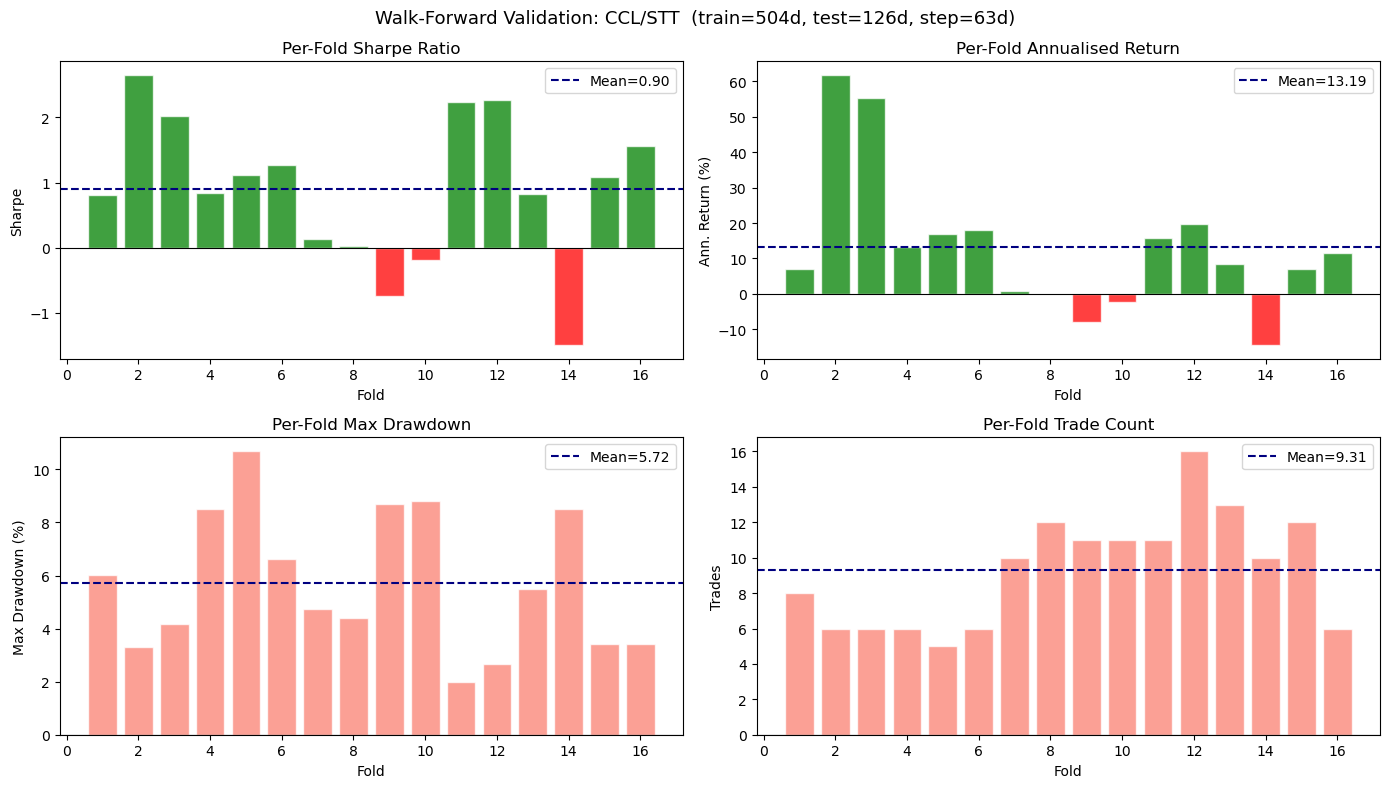


Folds with positive Sharpe : 81%  (13/16)
Median fold Sharpe         : 0.96
Mean fold Sharpe           : 0.90  (std=1.11)


In [17]:
# Per-fold walk-forward detail for the SELECTED pair — reuses wf_results from §3.5
# (no recomputation). nan-robust stats (a zero-trade fold yields a NaN Sharpe).
from pairs.validation.walk_forward import summarize_walk_forward

print(f"=== Walk-forward folds for selected pair {ticker1}/{ticker2} ===\n")
print(summarize_walk_forward(wf_results).to_string(float_format="{:.3f}".format))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {ticker1}/{ticker2}  "
             f"(train=504d, test=126d, step=63d)", fontsize=13)

sharpes  = wf_results["sharpe"].to_numpy(dtype=float)
ann_rets = wf_results["ann_return"].to_numpy(dtype=float) * 100
dds      = wf_results["max_drawdown_pct"].abs().to_numpy(dtype=float) * 100
n_trades = wf_results["n_trades"].to_numpy(dtype=float)
folds    = wf_results.index.values

def _bar(ax, vals, title, ylabel, pos_neg=True):
    colors = ["green" if v > 0 else "red" for v in vals] if pos_neg else "salmon"
    ax.bar(folds, vals, color=colors, alpha=0.75, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(np.nanmean(vals), color="navy", linestyle="--", lw=1.5,
               label=f"Mean={np.nanmean(vals):.2f}")
    ax.set_xlabel("Fold"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()

_bar(axes[0, 0], sharpes,  "Per-Fold Sharpe Ratio",      "Sharpe")
_bar(axes[0, 1], ann_rets, "Per-Fold Annualised Return", "Ann. Return (%)")
_bar(axes[1, 0], dds,      "Per-Fold Max Drawdown",      "Max Drawdown (%)", pos_neg=False)
_bar(axes[1, 1], n_trades, "Per-Fold Trade Count",       "Trades", pos_neg=False)
plt.tight_layout(); plt.show()

pct_pos = float(np.mean(sharpes > 0)) * 100
print(f"\nFolds with positive Sharpe : {pct_pos:.0f}%  ({int((sharpes > 0).sum())}/{len(sharpes)})")
print(f"Median fold Sharpe         : {np.nanmedian(sharpes):.2f}")
print(f"Mean fold Sharpe           : {np.nanmean(sharpes):.2f}  (std={np.nanstd(sharpes):.2f})")

## 3.6 Hyperparameter tuning — walk-forward on the training window only

nb02 picks the pair with a walk-forward driver but runs it with hand-set parameters. Here the same
folds (train 504 / test 126 / step 63 bars, 2020–2025) score a grid of configurations for the selected
pair. The objective is the one nb02 already uses for selection, **median out-of-fold Sharpe**, with a
minimum total trade count so that a config cannot win by trading twice.

The search is structured so that the expensive part is done once:

1. For each Kalman setting `(q, em_iters)` the filter is fitted on every training fold and run
   *causally* on the matching test fold (exactly `_sel_fit_fn` / `_sel_signal_fn` from §3.5). That gives
   per-fold frames with `P1, P2, beta, resid`. As in nb02's driver, the z-score look-back and its warm-up
   history come from the training fold's residual, never from the test fold.
2. Every signal configuration is then evaluated on those frames, which costs milliseconds per fold.

Nothing here touches 2026 data; the hold-out test in §4b is the only place the tuned configuration is
compared with the default on unseen prices.

In [18]:
from itertools import product
from pairs.validation import walk_forward_splits

TRAIN_BARS, TEST_BARS, STEP_BARS = 504, 126, 63     # same folds as the §3.5 selection driver

HP_DEFAULT = dict(q=1e-5, em_iters=5,                                    # nb02's hard-coded values
                  z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0,
                  max_hold_bars=None, cooldown_bars=0)
KALMAN_KEYS = ("q", "em_iters")
SIGNAL_KEYS = ("z_method", "z_entry", "z_exit", "z_stop", "max_hold_bars", "cooldown_bars")

KALMAN_GRID = [dict(q=q, em_iters=em) for q in (1e-6, 1e-5, 1e-4, 1e-3) for em in (0, 5)]
SIGNAL_GRID = [dict(z_method=m, z_entry=e, z_exit=x, z_stop=s, max_hold_bars=h, cooldown_bars=c)
               for m in ("robust", "rolling")
               for e in (1.5, 2.0, 2.5, 3.0)
               for x in (0.0, 0.5, 1.0)
               for s in (3.5, 4.0, 5.0)
               for h in (None, 60)
               for c in (0, 5)]
assert any({**k, **s} == HP_DEFAULT for k in KALMAN_GRID for s in SIGNAL_GRID), "default must be on the grid"
print(f"{len(KALMAN_GRID)} Kalman settings × {len(SIGNAL_GRID)} signal settings = "
      f"{len(KALMAN_GRID) * len(SIGNAL_GRID):,} configurations")

df_sel = prices_wide_tr[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}).dropna()
splits = walk_forward_splits(df_sel.index, train_bars=TRAIN_BARS, test_bars=TEST_BARS, step_bars=STEP_BARS)
print(f"{ticker1}/{ticker2}: {len(df_sel):,} training bars → {len(splits)} walk-forward folds")

8 Kalman settings × 288 signal settings = 2,304 configurations
CCL/STT: 1,508 training bars → 16 walk-forward folds


In [19]:
# ── Step 1: Kalman fits per fold, per (q, em_iters) — done once ─────────────────
def _kalman_key(q, em_iters):
    return f"q={q:g}, em={em_iters}"

def _fold_frame(df_train_f, df_test_f, q, em_iters):
    # Same mechanics as _sel_fit_fn + _sel_signal_fn in §3.5: EM fit on the train fold (filtered
    # states, so the residual history is causal), then continue the filter causally on the test
    # fold. The z-score look-back and its warm-up history come from the TRAIN fold only.
    _, _, states, params = _kalman_dynamic_hedge("P1", "P2", df_train_f, q=q, em_iters=em_iters,
                                                 mode="filter", return_params=True)
    if states is None or params is None:
        return None
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    states_te, _ = filter_kf_on_new(df_test_f["P1"], df_test_f["P2"], frozen=frozen,
                                    last_state=(params["last_state_mean"], params["last_state_cov"]),
                                    mode="filter")
    return {"frame": df_test_f[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner"),
            "z_window": estimate_halflife_window(states["resid"]),
            "z_history": states["resid"]}

def _fold_frames_for(df_pair_full, splits_, q, em_iters):
    warnings.filterwarnings("ignore")
    return [_fold_frame(df_pair_full.loc[tr], df_pair_full.loc[te], q, em_iters) for tr, te in splits_]

import time
t0 = time.time()
_frames = Parallel(n_jobs=N_JOBS)(delayed(_fold_frames_for)(df_sel, splits, **k) for k in KALMAN_GRID)
fold_frames = {_kalman_key(**k): f for k, f in zip(KALMAN_GRID, _frames)}
print(f"Kalman fold fits: {len(KALMAN_GRID)} settings × {len(splits)} folds in {time.time() - t0:.0f}s")

Kalman fold fits: 8 settings × 16 folds in 5s


In [20]:
# ── Step 2: evaluate every signal configuration on the precomputed folds ─────────
def _eval_config(kcfg, scfg, frames):
    warnings.filterwarnings("ignore")
    sharpes, trades = [], 0
    for f in frames:
        fr = None if f is None else f["frame"]
        if fr is None or len(fr) < 30:
            sharpes.append(np.nan); continue
        sig = generate_pair_signals(fr, capital_per_pair=10_000,
                                    z_window=f["z_window"], z_history=f["z_history"], **scfg)
        _, _, summ = evaluate_pair_signals(fr[["P1", "P2"]], sig,
                                           cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
        sharpes.append(summ["sharpe"]); trades += int(summ["n_trades"])
    s = np.asarray(sharpes, float)
    return {**kcfg, **scfg,
            "wf_sharpe_median": np.nanmedian(s) if np.isfinite(s).any() else np.nan,
            "wf_sharpe_mean":   np.nanmean(s)   if np.isfinite(s).any() else np.nan,
            "wf_sharpe_std":    np.nanstd(s)    if np.isfinite(s).any() else np.nan,
            "pct_pos_folds":    float(np.mean(s > 0)),
            "wf_trades_total":  trades,
            "n_folds":          int(np.isfinite(s).sum()),
            "fold_sharpes":     s}

t0 = time.time()
tuning = pd.DataFrame(Parallel(n_jobs=N_JOBS, batch_size=32)(
    delayed(_eval_config)(k, s, fold_frames[_kalman_key(**k)]) for k in KALMAN_GRID for s in SIGNAL_GRID))
print(f"{len(tuning):,} configurations × {len(splits)} folds evaluated in {time.time() - t0:.0f}s")

def _match(df, cfg):
    # None (max_hold_bars) becomes NaN inside a DataFrame column, so compare with isna() there.
    m = np.ones(len(df), dtype=bool)
    for k, v in cfg.items():
        m &= (df[k].isna() if v is None else (df[k] == v)).to_numpy()
    return m

default_row = tuning[_match(tuning, HP_DEFAULT)].iloc[0]
valid = tuning[tuning["wf_trades_total"] >= MIN_TOTAL_TRADES].sort_values("wf_sharpe_median", ascending=False)
print(f"{len(valid):,} configurations with ≥ {MIN_TOTAL_TRADES} total trades\n")

show_cols = list(KALMAN_KEYS + SIGNAL_KEYS) + ["wf_sharpe_median", "wf_sharpe_mean", "wf_sharpe_std", "pct_pos_folds", "wf_trades_total"]
print("Top 10 configurations by median out-of-fold Sharpe:")
print(valid[show_cols].head(10).to_string(index=False, float_format="{:.3f}".format))
print("\nnb02 default configuration:")
print(default_row[show_cols].to_frame().T.to_string(index=False, float_format="{:.3f}".format))
print(f"\nDefault ranks {int((valid['wf_sharpe_median'] > default_row['wf_sharpe_median']).sum()) + 1} "
      f"of {len(valid)} valid configurations.")

2,304 configurations × 16 folds evaluated in 44s
1,954 configurations with ≥ 12 total trades

Top 10 configurations by median out-of-fold Sharpe:
    q  em_iters z_method  z_entry  z_exit  z_stop  max_hold_bars  cooldown_bars  wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total
0.000         0  rolling    2.500   1.000   3.500            NaN              0             2.024           1.734          1.047          0.938               45
0.000         0  rolling    2.500   1.000   4.000            NaN              5             2.024           1.723          1.041          0.938               45
0.000         0  rolling    2.500   1.000   4.000         60.000              0             2.024           1.734          1.047          0.938               45
0.000         0  rolling    2.500   1.000   4.000         60.000              5             2.024           1.723          1.041          0.938               45
0.000         0  rolling    2.500   1.000   5.000

### 3.6.1 What matters and what does not

Marginal effect of each hyperparameter: the distribution of median out-of-fold Sharpe across all
configurations sharing a value (box = interquartile range across the other seven dimensions). A flat
row means the parameter does not matter much on this pair; a steep one is where the tuning gain comes
from.

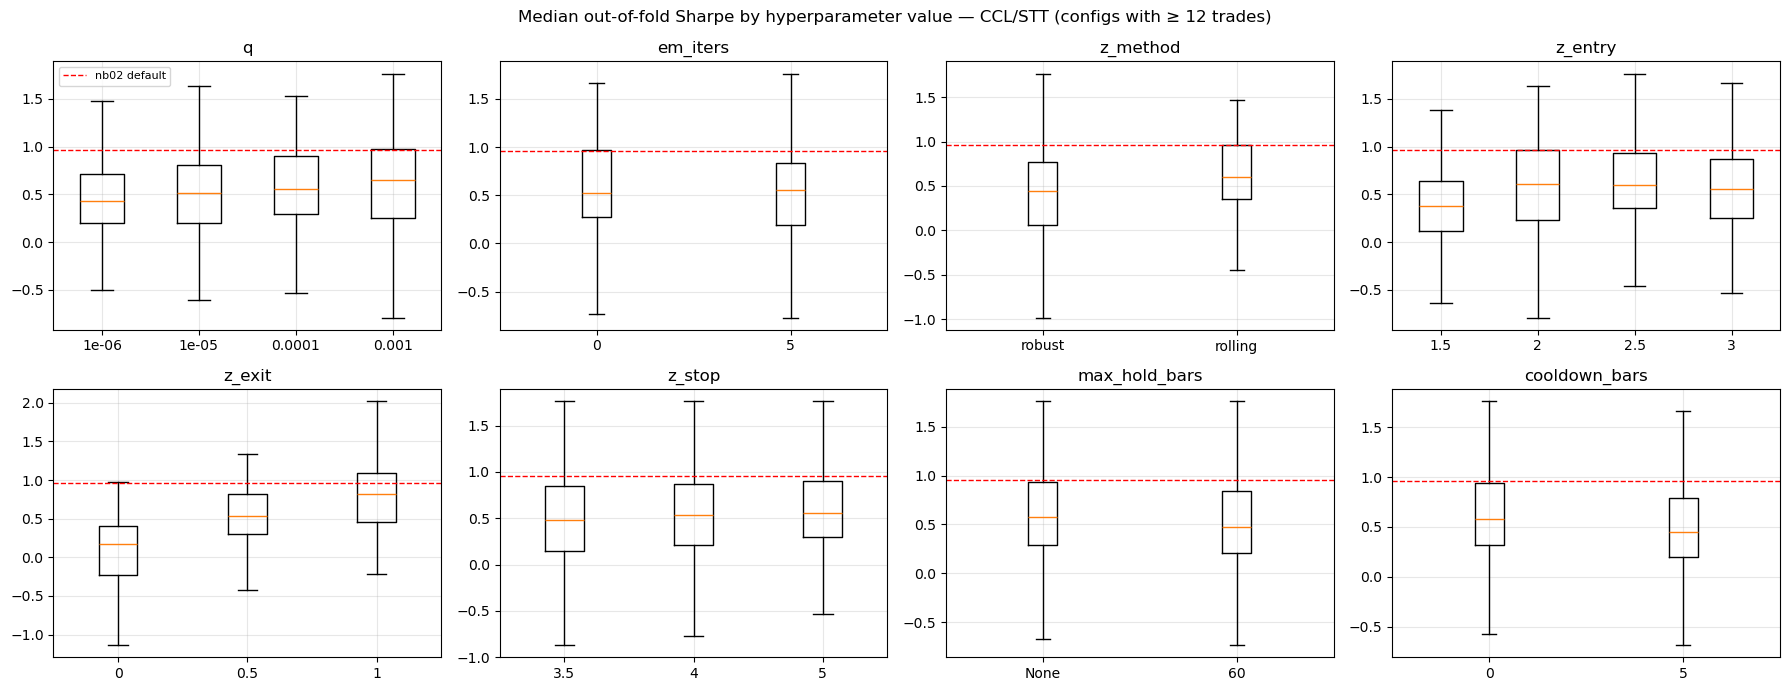

In [21]:
def _value_labels(series):
    # Human-readable group labels in a sensible order: 'None' first, then numeric ascending, or strings sorted.
    if pd.api.types.is_numeric_dtype(series):
        labels = series.map(lambda v: "None" if pd.isna(v) else f"{v:g}")
        order = (["None"] if series.isna().any() else []) + [f"{v:g}" for v in sorted(series.dropna().unique())]
    else:                                        # string-valued (pandas 3 'str' dtype or object)
        labels = series.astype(str); order = sorted(labels.unique())
    return labels, order

params_to_plot = list(KALMAN_KEYS + SIGNAL_KEYS)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, p in zip(axes.ravel(), params_to_plot):
    labels, order = _value_labels(valid[p])
    groups = valid.groupby(labels, sort=False)["wf_sharpe_median"]
    data = [groups.get_group(g).values for g in order if g in groups.groups]
    ticks = [g for g in order if g in groups.groups]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(ticks) + 1), ticks)      # works on matplotlib < 3.9 too
    ax.axhline(default_row["wf_sharpe_median"], color="red", ls="--", lw=1, label="nb02 default")
    ax.set_title(p); ax.grid(alpha=0.3)
    if p == params_to_plot[0]: ax.legend(fontsize=8)
fig.suptitle(f"Median out-of-fold Sharpe by hyperparameter value — {ticker1}/{ticker2} (configs with ≥ {MIN_TOTAL_TRADES} trades)")
plt.tight_layout(); plt.show()

### 3.6.2 How much of the improvement is selection bias?

Picking the maximum over a couple of thousand configurations guarantees a flattering in-sample number
even when nothing is really better. Two cheap checks before believing the winner:

* **Where the default sits** in the distribution of all configurations, and how far the top of the
  distribution is from its bulk (a lone outlier at the top is more suspicious than a plateau of similar
  configurations).
* **Split-half rank stability**: rank every configuration by its median Sharpe on the odd folds and
  again on the even folds. If tuning is finding structure rather than noise, the two rankings agree
  (Spearman correlation well above zero) and the winner on one half is near the top on the other.

The decisive check is the 2026 hold-out in §4b, which none of this has touched.

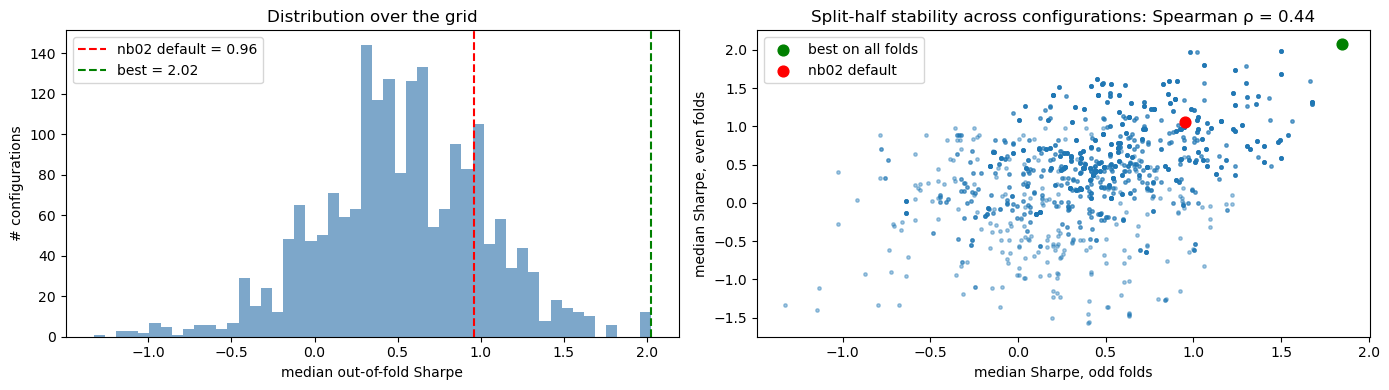

Top-20 configs by odd-fold Sharpe have median even-fold rank 6 of 1954  (pure noise would give ≈ 977).


In [22]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(valid["wf_sharpe_median"], bins=50, color="steelblue", alpha=0.7)
ax.axvline(default_row["wf_sharpe_median"], color="red", ls="--", label=f"nb02 default = {default_row['wf_sharpe_median']:.2f}")
ax.axvline(valid["wf_sharpe_median"].iloc[0], color="green", ls="--", label=f"best = {valid['wf_sharpe_median'].iloc[0]:.2f}")
ax.set_xlabel("median out-of-fold Sharpe"); ax.set_ylabel("# configurations"); ax.legend()
ax.set_title("Distribution over the grid")

# split-half rank stability
S = np.vstack(valid["fold_sharpes"].values)                       # configs × folds
odd, even = np.nanmedian(S[:, 0::2], axis=1), np.nanmedian(S[:, 1::2], axis=1)
ok = np.isfinite(odd) & np.isfinite(even)
rho = spearmanr(odd[ok], even[ok]).correlation
ax = axes[1]
ax.scatter(odd[ok], even[ok], s=6, alpha=0.4)
ax.scatter(odd[0], even[0], color="green", s=60, label="best on all folds", zorder=3)
if default_row.name in valid.index:            # the default may have too few trades to be 'valid'
    d_i = int(np.where(valid.index == default_row.name)[0][0])
    ax.scatter(odd[d_i], even[d_i], color="red", s=60, label="nb02 default", zorder=3)
ax.set_xlabel("median Sharpe, odd folds"); ax.set_ylabel("median Sharpe, even folds")
ax.set_title(f"Split-half stability across configurations: Spearman ρ = {rho:.2f}"); ax.legend()
plt.tight_layout(); plt.show()

top_k = 20
rank_even = pd.Series(even, index=valid.index).rank(ascending=False)
print(f"Top-{top_k} configs by odd-fold Sharpe have median even-fold rank "
      f"{rank_even.loc[valid.index[np.argsort(-odd)[:top_k]]].median():.0f} of {ok.sum()}  "
      f"(pure noise would give ≈ {ok.sum() / 2:.0f}).")

### 3.6.3 Choose the tuned configuration, and check it transfers

The winner is the best median out-of-fold Sharpe among configurations with enough trades. As a guard
against a configuration that is idiosyncratic to the selected pair, the same configuration is
re-scored on the next three candidates from the §3.5 shortlist (each with its own walk-forward folds):
a genuine improvement in the *strategy* should not evaporate on neighbouring pairs.

In [23]:
TUNED = {k: valid.iloc[0][k] for k in KALMAN_KEYS + SIGNAL_KEYS}
TUNED["q"] = float(TUNED["q"]); TUNED["em_iters"] = int(TUNED["em_iters"])
TUNED["max_hold_bars"] = None if pd.isna(TUNED["max_hold_bars"]) else int(TUNED["max_hold_bars"])
TUNED["cooldown_bars"] = int(TUNED["cooldown_bars"])
for k in ("z_entry", "z_exit", "z_stop"): TUNED[k] = float(TUNED[k])

print("Tuned configuration:")
for k in KALMAN_KEYS + SIGNAL_KEYS:
    flag = "" if TUNED[k] == HP_DEFAULT[k] else "   ← changed"
    print(f"  {k:14s} {str(HP_DEFAULT[k]):>8s} → {str(TUNED[k]):<8s}{flag}")

def _wf_score(pair, cfg):
    t1, t2 = pair
    dfp = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    sp = walk_forward_splits(dfp.index, train_bars=TRAIN_BARS, test_bars=TEST_BARS, step_bars=STEP_BARS)
    frames = _fold_frames_for(dfp, sp, cfg["q"], cfg["em_iters"])
    return _eval_config({k: cfg[k] for k in KALMAN_KEYS}, {k: cfg[k] for k in SIGNAL_KEYS}, frames)

others = [p for p in wf_selection.index if p != (ticker1, ticker2)][:3]
jobs = [(p, name, cfg) for p in [(ticker1, ticker2)] + others for name, cfg in (("default", HP_DEFAULT), ("tuned", TUNED))]
res = Parallel(n_jobs=N_JOBS)(delayed(_wf_score)(p, cfg) for p, name, cfg in jobs)
transfer = pd.DataFrame([{"pair": f"{p[0]}/{p[1]}", "config": name,
                          "wf_sharpe_median": r["wf_sharpe_median"], "pct_pos_folds": r["pct_pos_folds"],
                          "wf_trades_total": r["wf_trades_total"]} for (p, name, cfg), r in zip(jobs, res)])
transfer = transfer.pivot(index="pair", columns="config", values=["wf_sharpe_median", "pct_pos_folds", "wf_trades_total"])
transfer = transfer.reindex([f"{p[0]}/{p[1]}" for p in [(ticker1, ticker2)] + others])
print("\nWalk-forward score of the default vs tuned configuration (selected pair first, then runner-ups):")
print(transfer.to_string(float_format="{:.3f}".format))

Tuned configuration:
  q                 1e-05 → 1e-06      ← changed
  em_iters              5 → 0          ← changed
  z_method         robust → rolling    ← changed
  z_entry             2.0 → 2.5        ← changed
  z_exit              0.5 → 1.0        ← changed
  z_stop              4.0 → 3.5        ← changed
  max_hold_bars      None → None    
  cooldown_bars         0 → 0       



Walk-forward score of the default vs tuned configuration (selected pair first, then runner-ups):
         wf_sharpe_median       pct_pos_folds       wf_trades_total       
config            default tuned       default tuned         default  tuned
pair                                                                      
CCL/STT             0.960 2.024         0.812 0.938         149.000 45.000
CCL/EXPE            0.684 0.688         0.625 0.562         136.000 35.000
NCLH/SPG            0.425 0.185         0.625 0.562         138.000 35.000
NCLH/TEL            0.238 1.045         0.625 0.625         154.000 36.000



# 4. In-Sample Signal Generation & Evaluation (2020–2025) — default vs tuned

Same steps as nb02, run twice: once with nb02's defaults and once with the tuned configuration.
The tuned Kalman setting needs its own fit on the full training window (nb02's `states_tr`
were fitted with `q=1e-5, em_iters=5`).


In [24]:

prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'),
    columns=df_filtered.index.get_level_values('ticker'),
    values='close',
)
pair = (ticker1, ticker2)

# default Kalman states: from §3 (q=1e-5, em_iters=5)
df_pair = pd.DataFrame({'P1': prices[ticker1], 'P2': prices[ticker2]}).join(states_tr[pair][['beta', 'resid']])

# tuned Kalman states: refit on the full training window with the tuned (q, em_iters)
states_tuned, params_tuned = fit_kalman_hedge(
    df_train, pairs=[pair], mode="smooth",
    q=TUNED["q"], em_iters=TUNED["em_iters"], show_progress=False, return_params=True,
)
df_pair_tuned = pd.DataFrame({'P1': prices[ticker1], 'P2': prices[ticker2]}).join(states_tuned[pair][['beta', 'resid']])

print(f"Training pair frame: {df_pair.index[0].date()} → {df_pair.index[-1].date()}, {len(df_pair):,} bars")
print(f"Kalman (default) Q diag: {np.diag(params_tr[pair]['Q'])},  R: {params_tr[pair]['R'].ravel()}")
print(f"Kalman (tuned)   Q diag: {np.diag(params_tuned[pair]['Q'])},  R: {params_tuned[pair]['R'].ravel()}")
df_pair_tuned.tail(3)


Training pair frame: 2020-01-02 → 2025-12-31, 1,508 bars
Kalman (default) Q diag: [3.29199469e-05 1.01904941e-05],  R: [0.21507903]
Kalman (tuned)   Q diag: [1.e-06 1.e-06],  R: [1.]


,P1,P2,beta,resid
datetime,,,,
2025-12-29,30.719999,131.690002,0.324769,0.098467
2025-12-30,30.820000,130.339996,0.324946,0.613809
2025-12-31,30.540001,129.009995,0.325043,0.753448


## 4.2 Generate trading signals

Signal logic:
- **Entry**: |z| > `z_entry` (default 2.0) — spread is extreme
- **Exit** : |z| < `z_exit`  (default 0.5) — spread has mean-reverted
- **Stop** : |z| > `z_stop`  (default 4.0) — spread is diverging

Z-score is computed with the *robust* method (median/MAD) which is less sensitive to outliers.

In [25]:

from pairs.strategies import generate_pair_signals

SIG_DEFAULT = {k: HP_DEFAULT[k] for k in SIGNAL_KEYS}
SIG_TUNED   = {k: TUNED[k] for k in SIGNAL_KEYS}

signals       = generate_pair_signals(df_pair,       capital_per_pair=10_000, **SIG_DEFAULT)
signals_tuned = generate_pair_signals(df_pair_tuned, capital_per_pair=10_000, **SIG_TUNED)
print(f"in-sample trades — default: {int(signals['entry'].sum())}, tuned: {int(signals_tuned['entry'].sum())}")
signals_tuned.tail(5)


in-sample trades — default: 86, tuned: 26


,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2025-12-24,0.756443,0,0.0,0.0,False,False,False
2025-12-26,0.177345,0,0.0,0.0,False,False,False
2025-12-29,0.321110,0,0.0,0.0,False,False,False
2025-12-30,0.764439,0,0.0,0.0,False,False,False
2025-12-31,0.869875,0,0.0,0.0,False,False,False


## 4.3 Visualise in-sample trades (tuned configuration)

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • CCL (top), STT (bottom)'}, ylabel='Price'>))

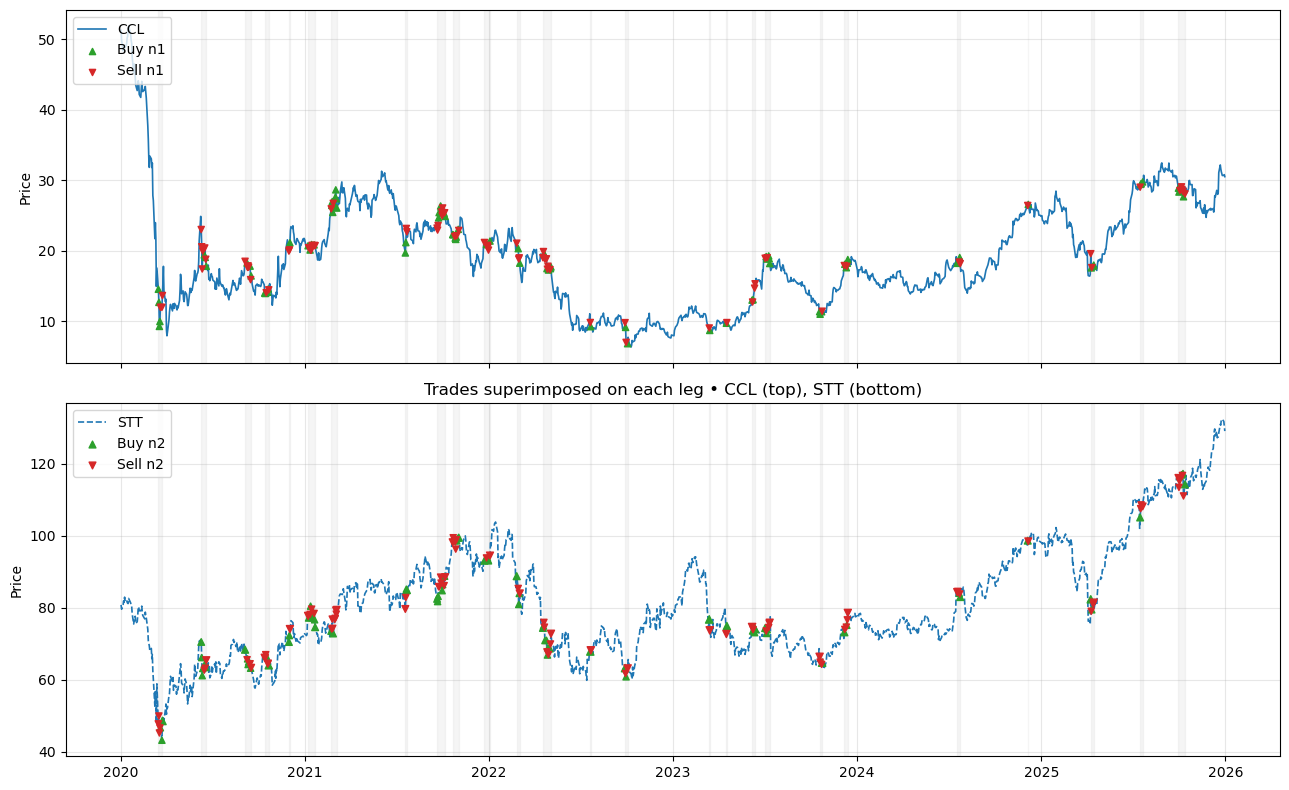

In [26]:

from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_tuned, signals_tuned,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)


## 4.4 In-sample performance metrics

In [27]:

from pairs import evaluate_pair_signals

COSTS = dict(cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
             borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)

daily_tr,   trades_tr,   summary_tr   = evaluate_pair_signals(df_pair,       signals,       **COSTS)
daily_tr_t, trades_tr_t, summary_tr_t = evaluate_pair_signals(df_pair_tuned, signals_tuned, **COSTS)

print("=== In-Sample Performance (2020-01-02 → 2025-12-31) ===")
print(pd.DataFrame({"default": pd.Series(summary_tr), "tuned": pd.Series(summary_tr_t)}).to_string())


=== In-Sample Performance (2020-01-02 → 2025-12-31) ===
                                      default                tuned
start                     2020-01-02 00:00:00  2020-01-02 00:00:00
end                       2025-12-31 00:00:00  2025-12-31 00:00:00
bars                                     1508                 1508
capital_base                     10008.298817         10013.002462
gross_pnl                         21261.95394          7141.229905
net_pnl                          21061.938536          7073.326271
ann_return                           0.406904             0.120809
sharpe                               2.454263             1.315421
max_drawdown                       1075.68772           948.801293
max_drawdown_pct                     0.044864             0.088821
avg_gross_exposure                1600.510632            904.92973
avg_exposure_utilization             1.000651              0.99479
turnover_annualized                   29.3803             9.119304
n_trad

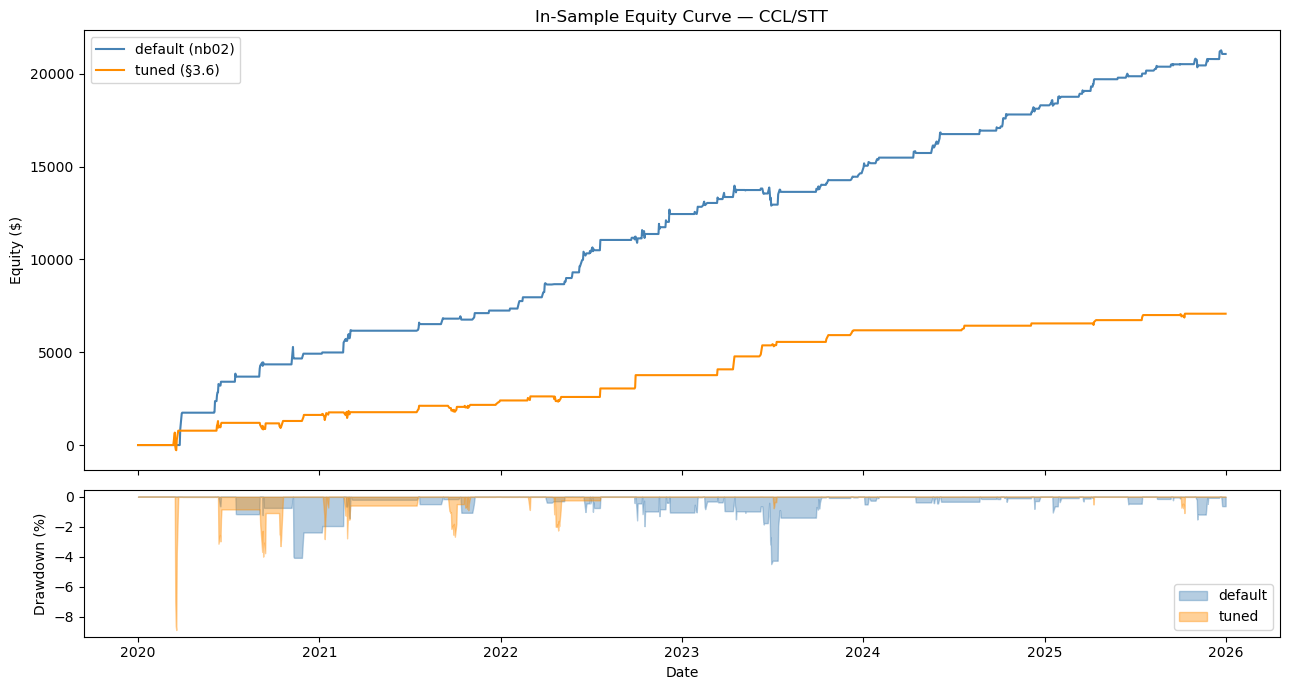

In [28]:

# Equity curves: default vs tuned (in-sample — the tuned curve is optimistic by construction)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(daily_tr.index,   daily_tr["equity"],   color="steelblue", lw=1.5, label="default (nb02)")
ax1.plot(daily_tr_t.index, daily_tr_t["equity"], color="darkorange", lw=1.5, label="tuned (§3.6)")
ax1.set_ylabel("Equity ($)"); ax1.set_title(f"In-Sample Equity Curve — {ticker1}/{ticker2}"); ax1.legend()
ax2.fill_between(daily_tr.index,   daily_tr["drawdown_pct"] * 100,   0, alpha=0.4, color="steelblue", label="default")
ax2.fill_between(daily_tr_t.index, daily_tr_t["drawdown_pct"] * 100, 0, alpha=0.4, color="darkorange", label="tuned")
ax2.set_ylabel("Drawdown (%)"); ax2.set_xlabel("Date"); ax2.legend()
plt.tight_layout(); plt.show()



# 4b. Out-of-Sample Evaluation (2026-01-01 → 2026-06-25) — the only honest comparison

The tuned configuration was chosen on 2020–2025 folds; the default was chosen by hand. Both are now run
on the same 2026 window, which neither has seen. The Kalman filter is continued causally from each
configuration's own end-of-training state.


In [29]:

start_test = "2026-01-01"
end_test   = "2026-06-25"

_oos_cache = CACHE / f"nb04_oos_{ticker1}_{ticker2}.parquet"
if _oos_cache.exists():
    df_test, failed = pd.read_parquet(_oos_cache), []
else:
    df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)
    df_test.to_parquet(_oos_cache)
print(f"OOS data: {len(df_test):,} rows, {df_test.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)


Download:   0%|          | 0/2 [00:00<?, ?it/s]

CCL:   0%|          | 0/2 [00:00<?, ?it/s]     

CCL:  50%|█████     | 1/2 [00:00<00:00,  9.57it/s]

STT:  50%|█████     | 1/2 [00:00<00:00,  9.57it/s]

STT: 100%|██████████| 2/2 [00:00<00:00, 10.01it/s]

OOS data: 240 rows, 2 tickers


## 4b.2 Continue Kalman filter on OOS window (no look-ahead)

We freeze the parameters $(F, Q, R)$ learned during training and **continue filtering**
from the last train state.  The smoother is NOT used on OOS data — only the causal filter.

The OOS z-score uses a look-back chosen from — and warmed up on — the causal *training-window* residual under the same frozen parameters, so the OOS window never informs its own z-score.

In [30]:

from pairs import filter_kf_on_new

P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']
prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close",
)

def _continue(params):
    frozen = {k: params[k] for k in ("F", "Q", "R")}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(P1_new, P2_new, frozen=frozen, last_state=last_state, init_cov=1e6, mode="filter")
    df_te = states_te.join(prices_te[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}), how="inner")
    # Causal residual over the TRAINING window under the same frozen parameters: it sets the z-score
    # look-back and warms it up, so the OOS window never informs its own z-score (nb02's fix).
    states_hist, _ = filter_kf_on_new(df_pair["P1"], df_pair["P2"], frozen=frozen, last_state=None, init_cov=1e6, mode="filter")
    return df_te, states_hist["resid"]

df_pair_te,   z_hist_default = _continue(params_tr[pair])       # default Kalman, continued
df_pair_te_t, z_hist_tuned   = _continue(params_tuned[pair])    # tuned Kalman, continued
print(f"OOS pair frame: {df_pair_te.index[0].date()} → {df_pair_te.index[-1].date()}, {len(df_pair_te):,} bars")
print(f"z-score windows from training residual — default: {estimate_halflife_window(z_hist_default)} bars, "
      f"tuned: {estimate_halflife_window(z_hist_tuned)} bars")


OOS pair frame: 2026-01-02 → 2026-06-25, 120 bars
z-score windows from training residual — default: 30 bars, tuned: 30 bars


In [31]:

signals_te   = generate_pair_signals(df_pair_te,   capital_per_pair=10_000, z_history=z_hist_default,
                                     z_window=estimate_halflife_window(z_hist_default), **SIG_DEFAULT)
signals_te_t = generate_pair_signals(df_pair_te_t, capital_per_pair=10_000, z_history=z_hist_tuned,
                                     z_window=estimate_halflife_window(z_hist_tuned), **SIG_TUNED)

daily_te,   trades_te,   summary_te   = evaluate_pair_signals(df_pair_te[["P1", "P2"]],   signals_te,   **COSTS)
daily_te_t, trades_te_t, summary_te_t = evaluate_pair_signals(df_pair_te_t[["P1", "P2"]], signals_te_t, **COSTS)

print("=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===")
print(pd.DataFrame({"default": pd.Series(summary_te), "tuned": pd.Series(summary_te_t)}).to_string())


=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===
                                      default                tuned
start                     2026-01-02 00:00:00  2026-01-02 00:00:00
end                       2026-06-25 00:00:00  2026-06-25 00:00:00
bars                                      120                  120
capital_base                      9982.860722          9916.509218
gross_pnl                          695.049266          -100.638113
net_pnl                            678.794022          -106.378401
ann_return                           0.147801             -0.02383
sharpe                               1.438988            -0.400239
max_drawdown                       332.334722           549.544095
max_drawdown_pct                     0.032708             0.054976
avg_gross_exposure                1751.634176          1073.267739
avg_exposure_utilization             1.002652              0.99905
turnover_annualized                 29.881713              8.86064
n_

## 4b.3 Visualise OOS trades (tuned configuration)

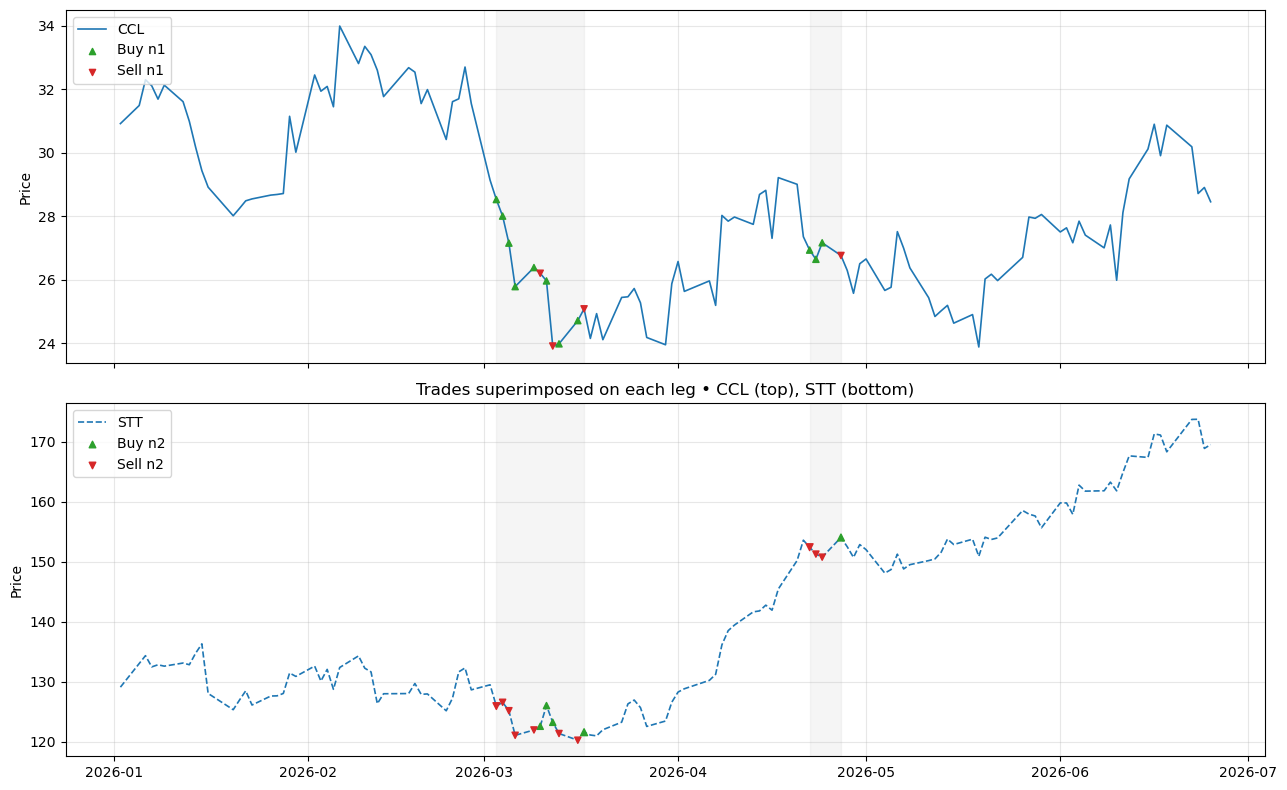

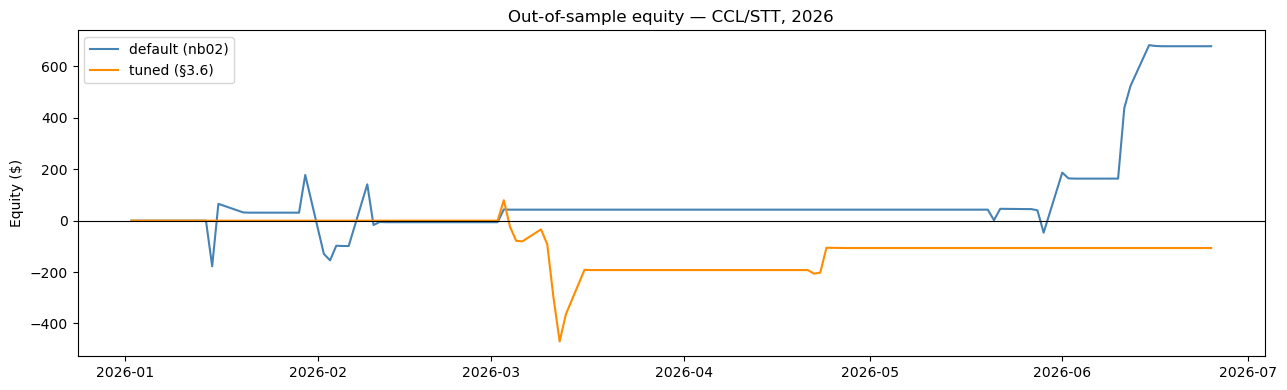

In [32]:

from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_te_t, signals_te_t,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_te.index,   daily_te["equity"],   color="steelblue",  lw=1.5, label="default (nb02)")
ax.plot(daily_te_t.index, daily_te_t["equity"], color="darkorange", lw=1.5, label="tuned (§3.6)")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Out-of-sample equity — {ticker1}/{ticker2}, 2026"); ax.set_ylabel("Equity ($)"); ax.legend()
plt.tight_layout(); plt.show()



## 4b.4 In-sample vs OOS, default vs tuned

Two things to keep in mind when reading the table:

* The **in-sample** columns use nb02's smoothed, EM-fitted Kalman states over the whole training window —
  a fit that looks at the future of every bar — so they overstate everything, and they can rank the two
  configurations differently from the walk-forward folds, which filter causally. The fold median in §3.6 is
  the right in-sample yardstick; the IS columns are here for continuity with nb02.
* The **OOS** columns are the evidence, but half a year yields a handful of trades: they can show a tuned
  configuration failing, they cannot show it succeeding with any confidence.


In [33]:

rows = ["sharpe", "ann_return", "max_drawdown_pct", "n_trades", "hit_rate", "profit_factor"]
comparison = pd.DataFrame({
    "IS default": pd.Series(summary_tr),   "IS tuned": pd.Series(summary_tr_t),
    "OOS default": pd.Series(summary_te),  "OOS tuned": pd.Series(summary_te_t),
}).loc[rows]
comparison.loc["ann_return"] = comparison.loc["ann_return"] * 100
comparison.index = ["Sharpe", "Ann. Return (%)", "Max Drawdown (%)", "Trades", "Hit Rate", "Profit Factor"]
print(comparison.to_string(float_format="{:.3f}".format))


                 IS default IS tuned OOS default OOS tuned
Sharpe                2.454    1.315       1.439    -0.400
Ann. Return (%)      40.690   12.081      14.780    -2.383
Max Drawdown (%)      0.045    0.089       0.033     0.055
Trades                   86       26           7         2
Hit Rate              0.919    0.885       0.857     0.500
Profit Factor        20.594   63.936       6.327     0.454


## 4b.5 What this tuning run actually found

Numbers refer to the run stored in this notebook (deterministic given the cached prices; a fresh
download shifts them slightly).

* **The grid finds "better" configurations easily.** The best median out-of-fold Sharpe is 2.02 against
  0.96 for nb02's defaults, which rank around 390th of ~1,950 valid configurations. The winner is a
  *stiffer and quieter* strategy: `q=1e-6` with no EM (a nearly static hedge ratio), rolling rather than
  robust z-scores, entry at 2.5 and exit at 1.0 — about a third as many trades as the default, on the
  folds (45 vs 149) and in the full in-sample run (26 vs 86).
* **Within the pair, the ranking is stable.** Configurations ranked on the odd folds keep a median rank of
  6 of ~1,950 on the even folds (pure noise: ~980; Spearman ρ ≈ 0.44 across the whole grid), and the
  winner is the best configuration on both halves separately. The top of the grid is nonetheless a
  plateau of configurations that differ only in parameters that never bind (`z_stop`, holding cap,
  cooldown) — they produce the same trades.
* **It transfers only partly.** On the runner-up pairs the tuned configuration helps NCLH/TEL
  (0.24 → 1.05), is neutral on CCL/EXPE (0.68 → 0.69) and hurts NCLH/SPG (0.43 → 0.19) (§3.6.3).
* **Out of sample it did not help.** On the 2026 hold-out the default made seven trades, six of them
  winners (Sharpe 1.4), while the tuned configuration made two, one of them a loser (Sharpe −0.4). With
  two to seven trades neither number is statistically meaningful, but the direction is the one
  selection bias predicts.

The honest reading is a little different from "mostly noise": the fold-level ranking is reproducible
*within* CCL/STT, so the tuned configuration is a genuine description of that pair's 2020–2025
behaviour — and that is exactly the problem. A configuration that fits one pair's regime (a static
hedge, wide entry, early exit) is not evidence about the *strategy*, as the mixed transfer and the losing
hold-out show. What the exercise does establish is *which* knobs matter on this pair (§3.6.1): the exit
threshold dominates (exiting only at the mean, `z_exit=0`, is clearly worse than 0.5 or 1.0), the entry
threshold matters at the low end (1.5 is worse than 2.0–3.0), the Kalman noise has a mild effect — and
the winner sits at the `q` value with the *lowest* marginal median, i.e. it is an outlier of its own
group. `em_iters`, `z_stop`, the holding cap and the cooldown barely register; `z_method` slightly
favours rolling. A sensible next step is a much smaller search over `z_exit` and `z_entry` only, pooled
across the shortlist rather than fitted to one pair.

# 8. Limitations and Honest Assessment

## 8.1 What the results cannot tell us

The traded pair was chosen (§3.5) from a shortlist that itself survived a composite stationarity filter over a very large number of simultaneously-tested pairs. Read the performance with these caveats:

- **Selection bias.** Even with BH FDR correction *and* walk-forward-based selection, picking the best-ranked pair on validation folds inflates expectations. The OOS test window is held out, but validation-set selection bias remains.
- **Low OOS trade count.** The OOS window typically produces only a handful of trades (≈6 for the representative CCL/EXPE pair) — far below the ~50 needed for statistical power. A high hit rate on a few trades is uninformative.
- **OOS Sharpe decay.** In-sample Sharpe is systematically optimistic and the OOS figure is typically much lower. Likely causes: over-fitting to COVID-era volatility, cointegration breakdown, and regimes (e.g. an AI bull market) offering fewer reversion opportunities.
- **Optimistic cost model.** The in-sample/OOS evaluation uses a flat `cost_bps` with no market impact, fill/queue uncertainty, or borrow-availability variability.
- **Single-pair analysis.** A live strategy trades a *portfolio* of pairs — introducing cross-pair residual correlation, portfolio-level drawdown management, and signal interaction effects not captured here.

## 8.2 What the evidence does support

1. A working end-to-end pipeline (data → cointegration → Kalman hedge → signals → evaluation) with **causal OOS continuation** (no look-ahead).
2. **Honest pair selection**: the traded pair is chosen by walk-forward cross-fold stability (§3.5), not by in-sample ranking — and the held-out window is never used for selection.
3. **Multiple-testing handled**: BH FDR correction removes statistically spurious pairs.
4. **Honest degradation disclosure**: the OOS Sharpe is reported, not hidden, and the walk-forward distribution (§3.5.1) shows the spread across folds rather than one window.

## 8.3 Gap-to-production

| Gap | Required mitigation |
|-----|---------------------|
| Selection bias | Strict hold-out from inception; FDR + walk-forward selection already applied |
| Low OOS N | Longer OOS window; portfolio of 10+ pairs |
| No market impact | Square-root impact model + capacity analysis |
| Single-regime OOS | Rolling re-estimation in live trading |
| No portfolio risk mgmt | Residual-vol position sizing; cross-pair correlation |
| Borrow / execution | Pre-borrow checks; limit-order fill model |

### Tuning-specific caveats (this notebook)

* **One pair, one search.** The grid was scored on the selected pair's folds. The transfer check in
  §3.6.3 is a sanity check, not a portfolio-level validation; a configuration tuned across the whole
  shortlist (pooled objective) would be the next step.
* **Selection bias is not removed, only exposed.** Thousands of configurations are compared on the same
  16 folds; §3.6.2 shows how the winner sits relative to the bulk and whether rankings agree across
  fold halves, but only the 2026 hold-out is an unbiased read — and half a year is a short one.
* **The pair was selected with the default parameters.** Selection and tuning interact; tuning first
  and selecting afterwards (or jointly) changes which pair is traded.
* **Fixed costs, fixed folds.** Cost assumptions (1 bp, 50 bp/yr borrow) and the fold geometry
  (504/126/63) are not tuned and the results are conditional on them.
